
Training PyTorch...
Epoch 1/5, Loss: 1.771562, Time: 2.38s, Accuracy: 52.57%, Memory: 7.04 MB
Epoch 2/5, Loss: 0.585317, Time: 2.26s, Accuracy: 84.36%, Memory: 0.00 MB
Epoch 3/5, Loss: 0.409988, Time: 2.25s, Accuracy: 88.45%, Memory: 0.00 MB
Epoch 4/5, Loss: 0.355109, Time: 2.29s, Accuracy: 89.97%, Memory: 0.00 MB
Epoch 5/5, Loss: 0.323095, Time: 2.26s, Accuracy: 90.86%, Memory: 0.00 MB

Testing PyTorch...
Test Accuracy for PyTorch: 91.49%

Training PyPradie...
Epoch 1/5, Loss: 0.868204, Time: 1.32s, Accuracy: 77.61%, Memory: 4.30 MB
Epoch 2/5, Loss: 0.369522, Time: 1.23s, Accuracy: 89.82%, Memory: 0.00 MB
Epoch 3/5, Loss: 0.306096, Time: 1.23s, Accuracy: 91.42%, Memory: 0.00 MB
Epoch 4/5, Loss: 0.271550, Time: 1.24s, Accuracy: 92.31%, Memory: 0.00 MB
Epoch 5/5, Loss: 0.246505, Time: 1.41s, Accuracy: 92.97%, Memory: 0.00 MB

Testing PyPradie...
Test Accuracy for PyPradie: 93.36%


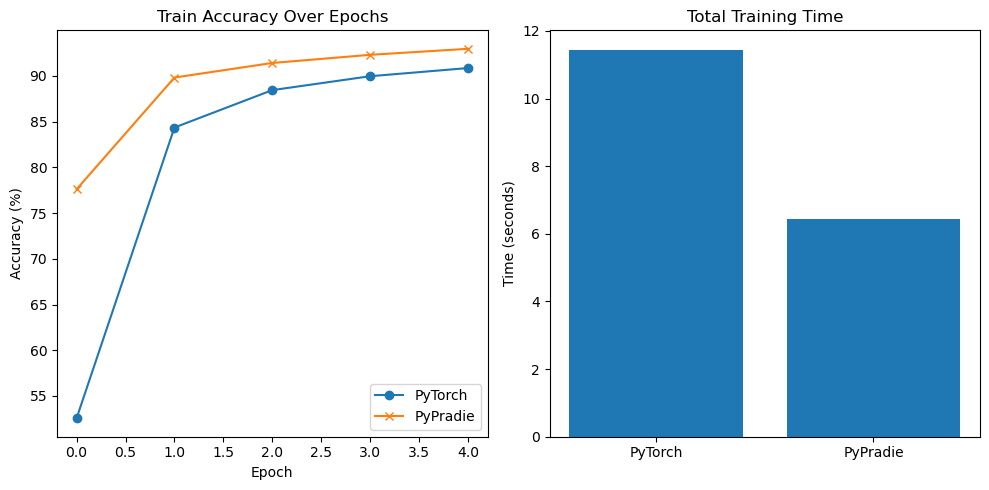


| Metric            | PyTorch Value   | PyPradie Value   |
|-------------------|-----------------|------------------|
| Train Accuracy (%) | 90.86 | 92.97 |
| Test Accuracy (%)  | 91.49 | 93.36 |
| Total Training Time (s)  | 11.44 | 6.43 |
| Memory Usage (MB)  | 1.41 | 0.86 |


In [1]:
import time
import psutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Function to dynamically load the correct library (PyTorch or PyPradie)
def get_framework(library_name):
    if library_name == "PyPradie":
        import pypradie as dl_framework
    else:
        import torch as dl_framework
    return dl_framework

# Function to load and preprocess the MNIST data
def load_data(dl_framework, batch_size=64):
    train_df = pd.read_csv('../datasets/mnist/mnist_train.csv')
    test_df = pd.read_csv('../datasets/mnist/mnist_test.csv')
    
    # Extract labels and normalize features
    train_labels = train_df['label'].values
    train_features = train_df.drop('label', axis=1).values / 255.0  # Normalize pixel values
    test_labels = test_df['label'].values
    test_features = test_df.drop('label', axis=1).values / 255.0
    
    # Convert to framework-specific tensors
    tensor = dl_framework.tensor
    train_features_tensor = tensor(train_features, dtype=dl_framework.float32)
    train_labels_tensor = tensor(train_labels, dtype=dl_framework.long)
    test_features_tensor = tensor(test_features, dtype=dl_framework.float32)
    test_labels_tensor = tensor(test_labels, dtype=dl_framework.long)
    
    # Use DataLoader for batching and shuffling
    DataLoader = dl_framework.utils.data.DataLoader
    TensorDataset = dl_framework.utils.data.TensorDataset
    train_dataset = TensorDataset(train_features_tensor, train_labels_tensor)
    test_dataset = TensorDataset(test_features_tensor, test_labels_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

# Function to build the model, loss function, and optimizer
def build_model(dl_framework):
    nn = dl_framework.nn
    model = nn.Sequential(
        nn.Linear(28 * 28, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10),
    )
    criterion = nn.CrossEntropyLoss()
    optimizer = dl_framework.optim.SGD(model.parameters(), lr=0.01)
    return model, criterion, optimizer

# Memory usage tracking
def memory_usage_psutil():
    """Return the memory usage in MB."""
    process = psutil.Process()
    mem_info = process.memory_info()
    return mem_info.rss / 1024 ** 2  # Memory in MB

# Training function with memory usage tracking
def train_model(dl_framework, model, criterion, optimizer, train_loader, epochs=5):
    tracking_data = {'train_accuracy': [], 'train_loss': [], 'epoch_time': [], 'memory_usage': []}
    tensor = dl_framework.tensor
    
    for epoch in range(epochs):
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        start_time = time.time()
        
        # Capture memory before training
        memory_before = memory_usage_psutil()
        
        for images, labels in train_loader:
            images = images.view(images.size(0), -1)  # Flatten images
            optimizer.zero_grad()  # Zero gradients
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            loss.backward()  # Backpropagation
            optimizer.step()  # Optimization
            
            running_loss += loss.item()
            
            predicted = dl_framework.argmax(outputs.detach(), dim=1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
        
        # Capture memory after training
        memory_after = memory_usage_psutil()
        epoch_memory_usage = memory_after - memory_before  # Measure memory used during training
        
        epoch_time = time.time() - start_time
        train_accuracy = 100 * correct_train / total_train
        tracking_data['train_accuracy'].append(train_accuracy)
        tracking_data['train_loss'].append(running_loss / len(train_loader))
        tracking_data['epoch_time'].append(epoch_time)
        tracking_data['memory_usage'].append(epoch_memory_usage)
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.6f}, Time: {epoch_time:.2f}s, Accuracy: {train_accuracy:.2f}%, Memory: {epoch_memory_usage:.2f} MB")
    
    return tracking_data

# Testing function
def test_model(dl_framework, model, test_loader):
    correct_test = 0
    total_test = 0
    tensor = dl_framework.tensor
    
    with dl_framework.no_grad():  # Disable gradients for testing
        for images, labels in test_loader:
            images = images.view(images.size(0), -1)  # Flatten images
            outputs = model(images)
            predicted = dl_framework.argmax(outputs, dim=1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()
    
    test_accuracy = 100 * correct_test / total_test
    return test_accuracy

# Visualization functions for comparing accuracy and time
def plot_accuracy(pytorch_data, pypradie_data):
    plt.figure(figsize=(10, 5))
    
    # Accuracy comparison plot
    plt.subplot(1, 2, 1)
    plt.plot(pytorch_data['train_accuracy'], label='PyTorch', marker='o')
    plt.plot(pypradie_data['train_accuracy'], label='PyPradie', marker='x')
    plt.title('Train Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    
    # Time comparison plot
    plt.subplot(1, 2, 2)
    plt.bar(['PyTorch', 'PyPradie'], [sum(pytorch_data['epoch_time']), sum(pypradie_data['epoch_time'])])
    plt.title('Total Training Time')
    plt.ylabel('Time (seconds)')
    
    plt.tight_layout()
    plt.show()

# Function to create and display the result as a markdown table
def display_results_as_table(pytorch_data, pypradie_data, pytorch_test_acc, pypradie_test_acc):
    # Calculate average memory usage
    pytorch_memory = sum(pytorch_data['memory_usage']) / len(pytorch_data['memory_usage'])
    pypradie_memory = sum(pypradie_data['memory_usage']) / len(pypradie_data['memory_usage'])
    
    # Create a markdown table string with results
    table = f"""
| Metric            | PyTorch Value   | PyPradie Value   |
|-------------------|-----------------|------------------|
| Train Accuracy (%) | {pytorch_data['train_accuracy'][-1]:.2f} | {pypradie_data['train_accuracy'][-1]:.2f} |
| Test Accuracy (%)  | {pytorch_test_acc:.2f} | {pypradie_test_acc:.2f} |
| Total Training Time (s)  | {sum(pytorch_data['epoch_time']):.2f} | {sum(pypradie_data['epoch_time']):.2f} |
| Memory Usage (MB)  | {pytorch_memory:.2f} | {pypradie_memory:.2f} |
"""
    # Display the markdown table in a Jupyter Notebook
    display(Markdown(table))

# Main function to run the experiment and compare PyTorch and PyPradie
def compare_libraries():
    libraries = ['PyTorch', 'PyPradie']
    comparison_data = {}

    for library in libraries:
        dl_framework = get_framework(library)
        
        # Load data and build the model
        train_loader, test_loader = load_data(dl_framework)
        model, criterion, optimizer = build_model(dl_framework)
        
        # Train the model
        print(f"\nTraining {library}...")
        train_data = train_model(dl_framework, model, criterion, optimizer, train_loader)
        
        # Test the model
        print(f"\nTesting {library}...")
        test_accuracy = test_model(dl_framework, model, test_loader)
        print(f"Test Accuracy for {library}: {test_accuracy:.2f}%")
        
        # Store data for comparison
        comparison_data[library] = {'train_data': train_data, 'test_accuracy': test_accuracy}
    
    # Extract results for both libraries
    pytorch_data = comparison_data['PyTorch']['train_data']
    pypradie_data = comparison_data['PyPradie']['train_data']
    pytorch_test_acc = comparison_data['PyTorch']['test_accuracy']
    pypradie_test_acc = comparison_data['PyPradie']['test_accuracy']
    
    # Plot accuracy and time comparisons
    plot_accuracy(pytorch_data, pypradie_data)
    
    # Display results as a markdown table
    display_results_as_table(pytorch_data, pypradie_data, pytorch_test_acc, pypradie_test_acc)

# Run the comparison
compare_libraries()
